# Regime Cookbook — Oil / Products Mental Model

This notebook is a **trading playbook**, not just a results dump.

Goal: build a mental map of *when* each strategy tends to work, *why* the regime variable matters, and *what to check* when you see the signal on the desk.

| Section | What you learn |
|---------|----------------|
| 0 Setup | Load live cache or demo; symbology status |
| 1 Map of the complex | Curve, crack, vol — the raw objects you trade |
| 2 Strategy cards | Economic thesis → entry → failure modes |
| 3 Diagnostics | Buckets, PnL~regime regression, walk-forward |
| 4 Stress windows | How signals behaved in known breaks |
| 5 Desk checklist | What to do when a signal lights up |

**How to use:** flip `USE_LIVE` below. First live run caches parquet under `data/cache/`.

## 0 — Setup

In [3]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import BacktestConfig, HoldingConfig, HoldingMode, STRESS_WINDOWS
from data.curves import calendar_spread, contango_pct, crack_321
from data.inventory import curve_tightness_proxy, inventory_zscore
from data.synthetic import make_synthetic_complex
from engine.backtest import load_market_data, run_strategy
from engine.regime_analytics import analyze_trades
from engine.stress import stress_panels
from engine.walk_forward import oos_bucket_summary, walk_forward_thresholds
from reports.plots import (
    plot_bucket_bars,
    plot_curve_and_contango,
    plot_equity,
    plot_inventory_regime,
    plot_pnl_vs_regime,
    plot_spread_with_trades,
)
from strategies import STRATEGY_REGISTRY

plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# True = Bloomberg (cache-aware). False = synthetic demo.
USE_LIVE = True
ON_SERVER = False  # True for BPIPE
PRODUCT = "HO"
HOLD_DAYS = 20

holding = HoldingConfig(mode=HoldingMode.FIXED_DAYS, hold_days=HOLD_DAYS)
cfg = BacktestConfig(complex="US", holding=holding, on_server=ON_SERVER, use_cache=True)

if USE_LIVE:
    print("Loading US complex from Bloomberg (parquet cache if present)...")
    data = load_market_data(cfg)
else:
    print("Using SYNTHETIC data — for learning the workflow only.")
    data = make_synthetic_complex()

print("Curves:", list(data["curves"]))
print("Inventory empty?", data["inventory"] is None or data["inventory"].empty)
print("IV cols:", list(data["iv"].columns) if data.get("iv") is not None and not data["iv"].empty else None)

Loading US complex from Bloomberg (parquet cache if present)...
Curves: ['CL', 'XB', 'HO']
Inventory empty? True
IV cols: ['CL', 'XB', 'HO']


### Symbology status (from our validation)

| Data | Status | Notes |
|------|--------|-------|
| CL/XB/HO/CO/QS generics | OK | `CLn Comdty` etc. |
| ATM IV (`HIST_CALL_IMP_VOL`) | OK | CL/CO denser than XB; starts ~2015 usefully |
| EIA stocks (`DOEUSCR`…) | **Not returning** on this license | Use curve-tightness proxy, or drop CSV into `data/manual_inventory/eia_stocks.csv` |
| `IVOL_MID` | Empty | Stick with `HIST_CALL_IMP_VOL` |

XB/HO Bloomberg prints are **cents/gal** — the 3-2-1 crack converts `/100 * 42`.

## 1 — Map of the complex

Before strategies: know the three objects.

1. **Curve shape** — contango vs backwardation (storage / tightness)
2. **Crack** — refining margin (demand for products vs crude)
3. **Vol** — how expensive insurance is vs what realized

Grey bands = stress windows (2014–15 crash, COVID, Apr-2020 WTI neg, 2022 RU/UA, 2023 banking).

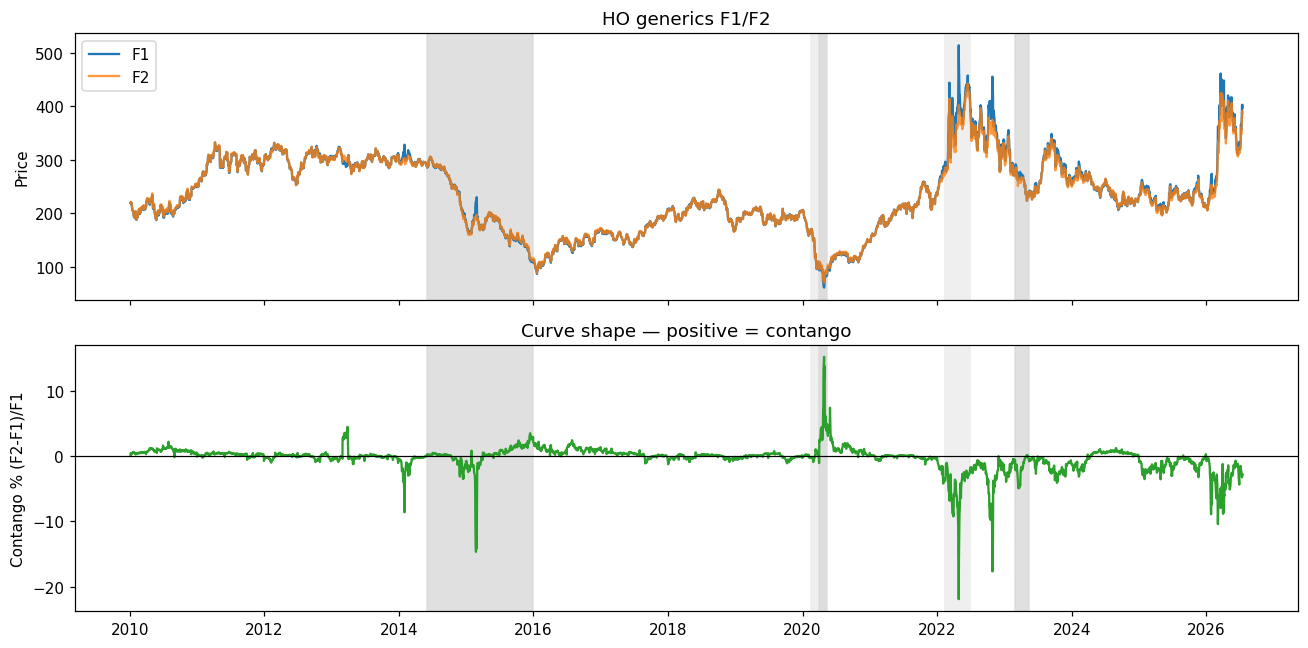

Contango % summary:
count   4,165.0000
mean       -0.0029
std         0.0186
min        -0.2195
25%        -0.0055
50%         0.0008
75%         0.0047
max         0.1527
dtype: float64
Share of days in backwardation (contango<0): 45.7%


In [4]:
cl = data["curves"][PRODUCT]
fig = plot_curve_and_contango(cl, title=f"{PRODUCT} generics F1/F2")
plt.show()

c = contango_pct(cl)
print("Contango % summary:")
print(c.describe())
print(f"Share of days in backwardation (contango<0): {(c < 0).mean():.1%}")

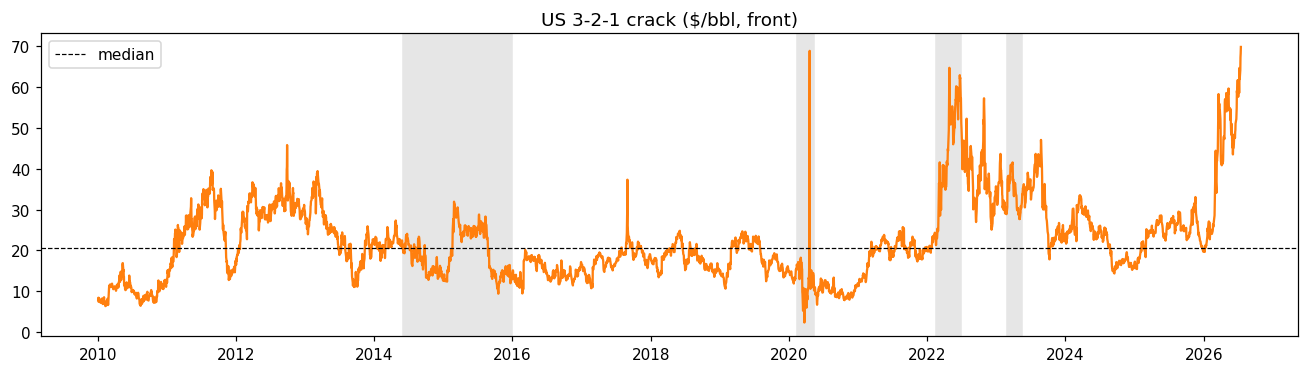

count   4,165.0000
mean       22.3666
std         9.8414
min         2.3958
25%        15.4342
50%        20.7120
75%        26.8258
max        69.7262
Name: F1, dtype: float64


In [5]:
if all(k in data["curves"] for k in ("CL", "XB", "HO")):
    crack = crack_321(data["curves"]["CL"], data["curves"]["XB"], data["curves"]["HO"])
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(crack.index, crack, color="C1")
    ax.axhline(crack.median(), color="k", ls="--", lw=0.8, label="median")
    ax.set_title("US 3-2-1 crack ($/bbl, front)")
    ax.legend()
    for _, (a, b) in STRESS_WINDOWS.items():
        ax.axvspan(a, b, color="0.9", zorder=0)
    plt.tight_layout()
    plt.show()
    print(crack.describe())
else:
    crack = None
    print("US crack legs missing")

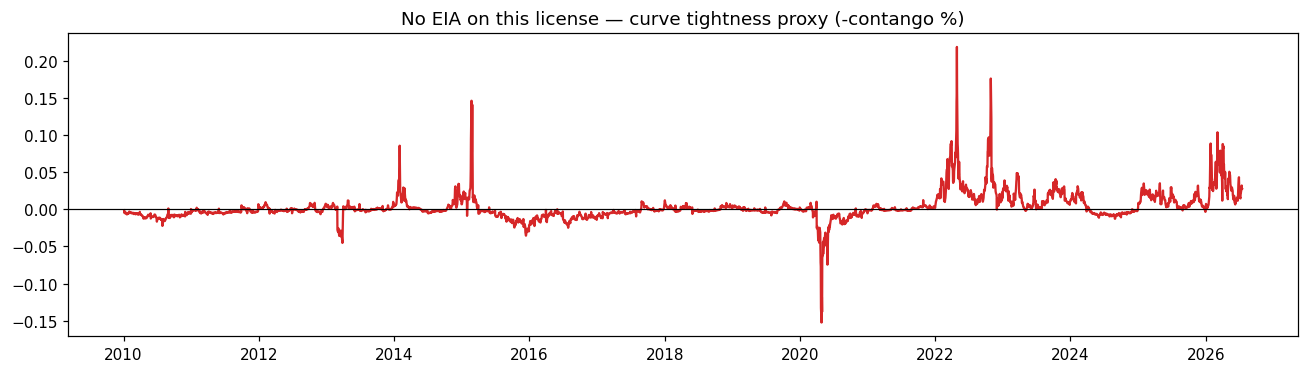

Using curve tightness PROXY (replace with EIA when available)


In [6]:
inv = data.get("inventory")
if inv is not None and not inv.empty and PRODUCT in inv.columns:
    z = inventory_zscore(inv[PRODUCT])
    plot_inventory_regime(inv[PRODUCT], z, title=f"{PRODUCT} EIA stocks")
    plt.show()
    regime_proxy_note = "Using true inventory z"
else:
    z = curve_tightness_proxy(cl)
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(z.index, z, color="C3")
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title("No EIA on this license — curve tightness proxy (-contango %)")
    plt.tight_layout()
    plt.show()
    regime_proxy_note = "Using curve tightness PROXY (replace with EIA when available)"
print(regime_proxy_note)

## 2 — Strategy cards (mental models)

Read each card as: **thesis → what you buy/sell → regime gate → when it dies**.

Then we run the strategy and overlay trades on the spread.

### Card A — Cash & Carry (`cash_and_carry`)

| | |
|--|--|
| **Economic thesis** | Rich contango embeds more carry than the market "should" sustain → curve often **flattens** (near outperforms deferred on a spread basis). |
| **Trade** | Long near / short deferred (futures-only flatten bet — *not* a financed physical storage arb). |
| **Regime gate** | Contango % in the upper expanding quantile (`contango`). |
| **Works when** | Storage ample, financials long the back, curve steep without a fundamental reason to stay steep. |
| **Dies when** | Contango is *structurally* needed (forced storage, logistics), or a squeeze flips the front violently (Apr 2020). |
| **Desk tell** | "Is contango rich vs recent history *and* vs my storage/financing mental full-carry?" If rich only vs history but still below full carry, be careful. |

### Card B — Calendar long (`calendar_spread`)

| | |
|--|--|
| **Economic thesis** | Tight inventories → prompt demand for barrels → **backwardation** / front strength. |
| **Trade** | Long F1−F2. |
| **Regime gate** | Low inventory z (or curve-tightness proxy if no EIA). |
| **Works when** | Draws are real (refinery runs, exports, weather) and the front is still not fully priced. |
| **Dies when** | "Low stocks" is seasonal and already in the curve; or SPR / policy floods prompt supply. |
| **Desk tell** | Stocks vs 5y *same week*, not vs last month. Same-week z is the point. |

### Card C — Crack mean reversion (`crack_mr`)

| | |
|--|--|
| **Economic thesis** | Cracks are mean-reverting *when* the process is stationary enough (finite half-life). |
| **Trade** | Fade rich/cheap 3-2-1 vs rolling z. |
| **Regime gate** | Half-life in a tradeable band (not noise-fast, not random-walk slow). |
| **Works when** | Margin spike from temporary outage / demand pulse that history says fades in weeks. |
| **Dies when** | Regime shift in refining (RU/UA 2022 diesel, structural demand). HL blows out → stop fading. |
| **Desk tell** | "Is this a z-score event or a new mean?" Half-life answering that is the whole point. |

### Card D — Vol calendar (`vol_calendar`)

| | |
|--|--|
| **Economic thesis** | Near-dated IV often overshoots into events; deferred IV is stickier. Sell rich near vs cheaper back. |
| **Trade** | Proxy: short near IV / long back IV (vol-point P&L — not full option reval). |
| **Regime gate** | High IV percentile and/or low RV/IV (implied rich vs realized). |
| **Works when** | Event premium decays, realized stays contained. |
| **Dies when** | Realized explodes (COVID, invasion) — short near vol is a short convexity position. |
| **Desk tell** | Always check **RV/IV** and whether you are short gamma into a binary. |

### Card E — Crack skew (`crack_skew`) & seasonal inventory

- **Crack skew**: RBOB vs HO relative value — gasoline season vs distillate winter; fade extremes when the complex isn't in a one-sided product shock.
- **Seasonal inventory**: curve still contango *despite* tight seasonal stocks → calendar may be mispriced (needs real EIA for best use).

## 3 — Run strategies + diagnostics

For each strategy we want three mental checks:

1. **Bucket table** — Does the *intended* regime bucket actually have better Sharpe/hit rate?
2. **Scatter PnL vs regime** — Linear edge (more regime → more PnL) vs **threshold** (only the extreme tail works)?
3. **Walk-forward** — Did the edge survive thresholds fit only on past data?

In [7]:
def run_card(key: str, **strat_kwargs):
    """Run one strategy and return trades + analysis bundle."""
    cls = STRATEGY_REGISTRY[key]
    strat = cls(holding=holding, product=PRODUCT, **strat_kwargs)
    trades = run_strategy(strat, data)
    if trades.empty:
        print(f"[{key}] no trades")
        return None
    analysis = analyze_trades(trades)
    folds, oos = walk_forward_thresholds(trades, cfg=cfg.walk_forward)
    stress = stress_panels(trades)
    # rebuild spread/regime for plots
    spread, regime, signal = strat.prepare(data)
    return {
        "key": key,
        "trades": trades,
        "analysis": analysis,
        "folds": folds,
        "oos": oos,
        "stress": stress,
        "spread": spread,
        "regime": regime,
        "signal": signal,
    }


def show_card(bundle):
    if bundle is None:
        return
    key = bundle["key"]
    print("=" * 72)
    print(key)
    print("=" * 72)
    display(bundle["analysis"]["buckets"])
    reg = bundle["analysis"]["regression"]
    print("Regression:", {k: reg[k] for k in reg if k != "statsmodels_linear"})

    plot_spread_with_trades(
        bundle["spread"],
        bundle["trades"],
        regime=bundle["regime"].continuous,
        title=f"{key}: spread + entries",
    )
    plt.show()

    plot_pnl_vs_regime(bundle["trades"], title=f"{key}: pnl_net vs regime_value")
    plt.show()

    plot_bucket_bars(bundle["analysis"]["buckets"], metric="sharpe_net", title=f"{key} Sharpe by bucket")
    plt.show()

    plot_equity(bundle["trades"], title=f"{key} equity (net)")
    plt.show()

    if bundle["folds"] is not None and not bundle["folds"].empty:
        print("Walk-forward folds (OOS):")
        display(bundle["folds"])
        display(oos_bucket_summary(bundle["oos"]))
    print("Stress windows:")
    display(bundle["stress"])

In [8]:
results = {}
for key, kwargs in [
    ("cash_and_carry", {}),
    ("calendar_spread", {}),
    ("crack_mr", {"complex_name": "US"}),
    ("vol_calendar", {}),
    ("crack_skew", {}),
]:
    print(f"\n>>> Running {key}...")
    results[key] = run_card(key, **kwargs)


>>> Running cash_and_carry...



>>> Running calendar_spread...

>>> Running crack_mr...

>>> Running vol_calendar...

>>> Running crack_skew...


TypeError: strategies.base.BaseStrategy.__init__() got multiple values for keyword argument 'product'

### Deep dive — pick one strategy

Change `FOCUS` to study a single card slowly.

crack_mr


,bucket,n,hit_rate,avg_pnl,total_pnl,sharpe,avg_pnl_net,sharpe_net
0,UNCONDITIONAL,120,0.5583,0.3741,44.8974,0.5549,0.3731,0.5535
1,tradeable,120,0.5583,0.3741,44.8974,0.5549,0.3731,0.5535


Regression: {'n': 120, 'linear': {'alpha': 0.3607780251115584, 'beta': 0.0007330394034648633, 't_beta': 0.01378641435078407, 'r2': 1.6107196147974179e-06}, 'quadratic': {'alpha': -2.025459783207922, 'beta': 0.29372155172659975, 'beta2': -0.005722731093573075, 't_beta': 1.3816531016982236, 't_beta2': -1.423038615788806, 'r2': 0.017015137108151723}, 'suggests_threshold_nonlinearity': False}


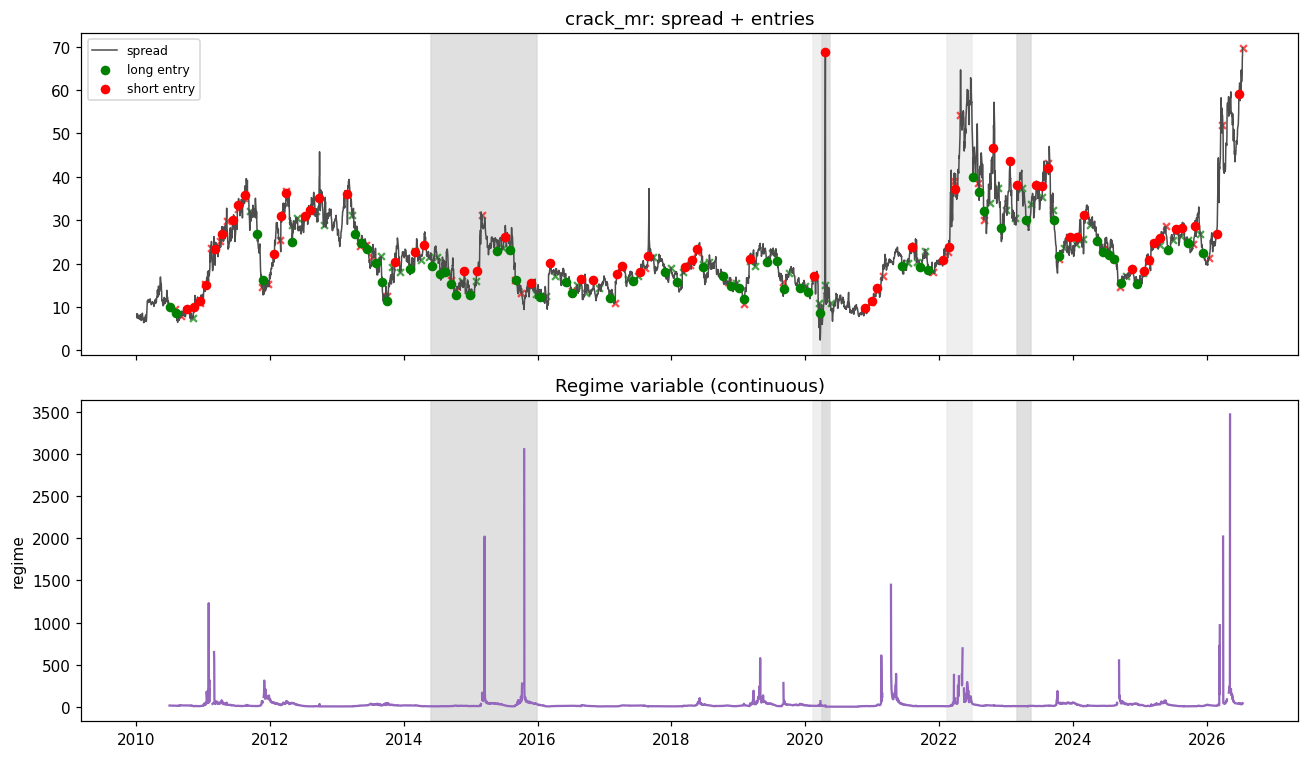

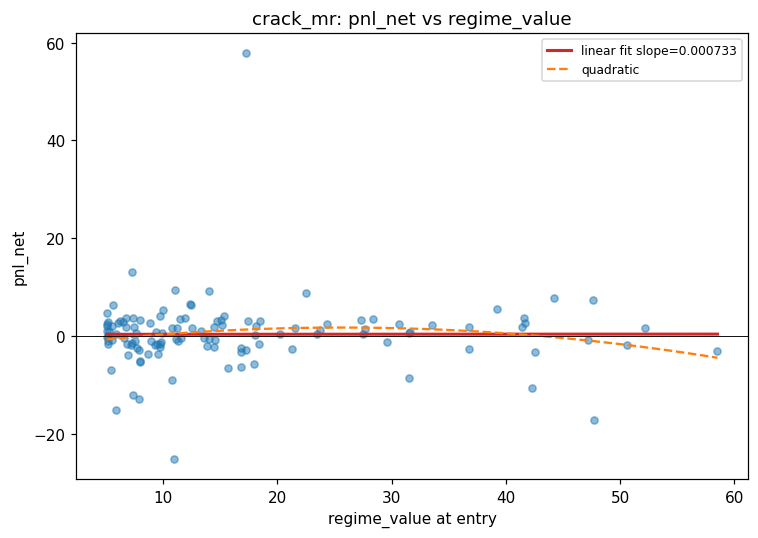

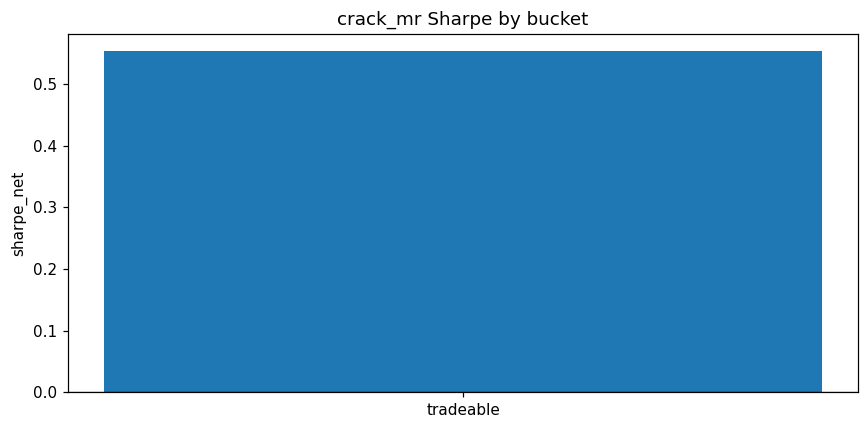

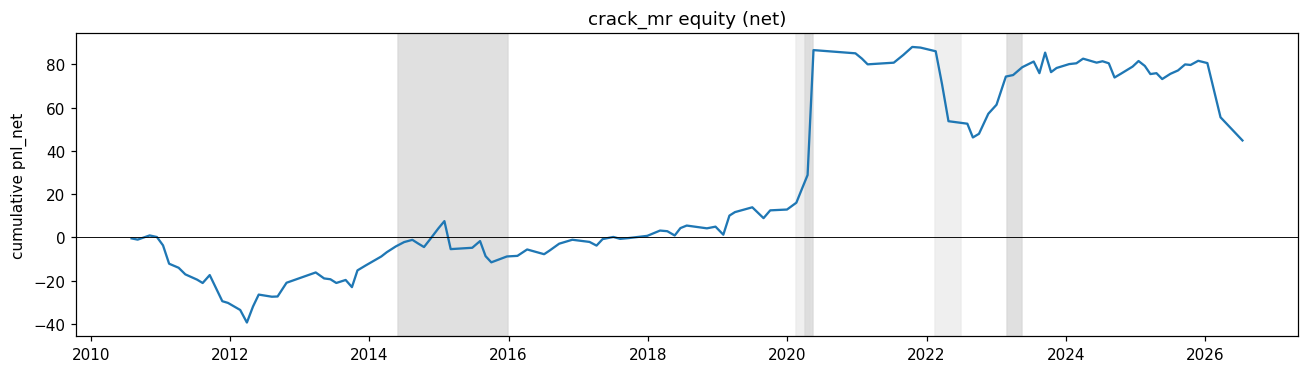

Walk-forward folds (OOS):


,train_start,train_end,test_start,test_end,q_low,q_high,n_test_trades,test_sharpe,test_hit_rate,test_avg_pnl
0,2010-07-02,2013-07-01,2013-07-02,2014-07-01,7.1986,40.5735,8,2.1815,0.8750,2.3645
1,2011-07-02,2014-07-01,2014-07-02,2015-07-01,6.5797,34.6123,8,-0.1646,0.6250,-0.3298
2,2012-07-02,2015-07-01,2015-07-02,2016-07-01,5.7987,17.5848,7,-0.2962,0.5714,-0.4247
3,2013-07-02,2016-07-01,2016-07-02,2017-07-01,6.4839,18.3229,7,1.6121,0.7143,1.1396
4,2014-07-02,2017-07-01,2017-07-02,2018-07-01,5.5820,17.3669,8,1.0629,0.6250,0.6588
5,2015-07-02,2018-07-01,2018-07-02,2019-07-01,5.2534,17.8781,6,0.8140,0.6667,1.4076
6,2016-07-02,2019-07-01,2019-07-02,2020-07-01,5.8856,21.5626,7,1.2921,0.8571,10.3860
7,2017-07-02,2020-07-01,2020-07-02,2021-07-01,9.3441,23.7163,4,-1.8586,0.2500,-1.4541
8,2021-07-02,2024-07-01,2024-07-02,2025-07-01,7.0704,18.1696,10,-0.5687,0.5000,-0.5816
9,2022-07-02,2025-07-01,2025-07-02,2026-06-25,8.7568,28.6777,7,-1.1431,0.4286,-4.4013


,wf_bucket,n,hit_rate,avg_pnl,total_pnl,sharpe,avg_pnl_net,sharpe_net
0,high,19,0.8947,1.7313,32.8940,1.9089,1.7303,1.9078
1,low,15,0.6000,0.4098,6.1464,0.5719,0.4088,0.5705
2,mid,38,0.5000,0.6918,26.2896,0.3887,0.6908,0.3881


Stress windows:


,window,start,end,n,hit_rate,avg_pnl,total_pnl,sharpe,avg_pnl_net,sharpe_net
0,oil_crash_2014_15,2014-06-01,2015-12-31,13,0.6154,-0.3554,-4.6208,-0.2555,-0.3564,-0.2562
1,covid_crash_2020,2020-02-15,2020-04-30,3,1.0000,23.5289,70.5868,1.3739,23.5279,1.3739
2,wti_negative_apr2020,2020-04-01,2020-05-15,1,1.0000,57.7796,57.7796,0.0000,57.7786,0.0000
3,russia_ukraine_2022,2022-02-15,2022-06-30,2,0.0000,-16.1733,-32.3466,-15.7068,-16.1743,-15.7078
4,banking_stress_2023,2023-03-01,2023-05-15,2,1.0000,2.1667,4.3334,1.4797,2.1657,1.4790


In [13]:
FOCUS = "crack_mr"  # cash_and_carry | calendar_spread | crack_mr | vol_calendar | crack_skew
show_card(results.get(FOCUS))

### How to read the regression (important)

| Pattern | Interpretation | How to trade it |
|---------|----------------|-----------------|
| Significant **linear** β, weak quadratic | More regime → more expected PnL (scale in) | Continuous lean / size with regime_z |
| Weak linear, strong **quadratic** / `suggests_threshold_nonlinearity` | Edge only in the tails | Binary: trade only extreme bucket |
| Good in-sample buckets, **bad walk-forward** | You curve-fit the threshold | Do not trust; widen or abandon |
| UNCONDITIONAL ≈ best bucket | Regime filter not adding value | Strategy may just be the trade, not the filter |

## 4 — Stress windows: building scar tissue

Ask for each crisis: *Did my regime filter keep me out, or did it shove me in at the worst time?*

| Window | What broke | Typical strategy stress |
|--------|------------|-------------------------|
| 2014–15 oil crash | Supply glut, contango explosion | C&C / calendars behave differently than "normal" contango |
| COVID Mar 2020 | Demand destruction, vol spike | Short vol dies; cracks gap |
| **Apr 2020 WTI neg** | Front expiry / storage scarcity paradox | Near-leg anything is lethal near expiry |
| 2022 RU/UA | Diesel / product regime shift | Crack MR half-life breaks (new mean) |
| 2023 banking | Liquidity / risk-off | Usually secondary for oil; watch vol risk premia |

In [ ]:
rows = []
for key, b in results.items():
    if b is None:
        continue
    s = b["stress"].copy()
    s.insert(0, "strategy", key)
    rows.append(s)
if rows:
    stress_all = pd.concat(rows, ignore_index=True)
    display(stress_all.pivot_table(index="window", columns="strategy", values="sharpe_net"))
    display(stress_all.pivot_table(index="window", columns="strategy", values="n"))

strategy,calendar_spread,cash_and_carry,crack_mr,vol_calendar
window,,,,
banking_stress_2023,0.0000,0.0000,1.4729,0.0000
covid_crash_2020,0.0000,0.0022,1.3733,0.0000
oil_crash_2014_15,-0.6314,0.0758,-0.2627,0.3454
russia_ukraine_2022,0.2095,0.0000,-15.7165,0.3677
wti_negative_apr2020,0.0000,-1.3734,0.0000,0.0000


strategy,calendar_spread,cash_and_carry,crack_mr,vol_calendar
window,,,,
banking_stress_2023,0.0000,0.0000,2.0000,1.0000
covid_crash_2020,1.0000,2.0000,3.0000,1.0000
oil_crash_2014_15,5.0000,13.0000,13.0000,6.0000
russia_ukraine_2022,5.0000,0.0000,2.0000,4.0000
wti_negative_apr2020,1.0000,2.0000,1.0000,0.0000


## 5 — Desk checklist (when a signal lights up)

Print this. Use it live.

### Universal (every signal)
1. What is the **regime value** today vs its 1y distribution? Extreme or merely "on"?
2. Is the half-life / persistence of the *driver* still in the band we backtested?
3. Am I inside a **stress window** analogue (event vol, expiry week, geopolitics)?
4. Costs: is the edge larger than ~1 full bid-ask on the structure?
5. What is my **kill criterion** before entry (regime flips, HL exits band, RV/IV > 1…)?

### By strategy
| Signal | Confirm | Abort if |
|--------|---------|----------|
| C&C / rich contango | Contango rich *and* inventories comfortable / not a squeeze | Front expiry < ~2 weeks; storage scare headlines |
| Calendar / tight | Stocks low vs **same week** 5y; curve not already max backwardated | SPR release / sudden supply; proxy-only without EIA |
| Crack fade | z>threshold **and** HL tradeable | Structural product shock (diesel 2022-style) |
| Vol calendar | IV %ile high **and** RV/IV soft | Binary event inside near tenor; RV already ripping |
| RBOB/HO skew | Seasonal story agrees with sign | One product in genuine shortage |

In [ ]:
def today_snapshot(key: str = "crack_mr"):
    """Latest regime reading + whether the strategy would be on."""
    b = results.get(key)
    if not b:
        print("Run strategies first")
        return
    sig = b["signal"].dropna()
    reg = b["regime"].continuous.dropna()
    state = b["regime"].state.dropna() if b["regime"].state is not None else None
    print(f"Strategy: {key}")
    print(f"Last date: {sig.index[-1].date()}")
    print(f"Signal: {int(sig.iloc[-1])}  (nonzero = would enter under current rules)")
    print(f"Regime value: {reg.iloc[-1]:.4f}")
    if state is not None:
        print(f"Regime state: {state.iloc[-1]}")
    # percentile of today's regime in last year
    one_y = reg.iloc[-252:] if len(reg) > 252 else reg
    pct = (one_y <= reg.iloc[-1]).mean()
    print(f"Regime percentile vs ~1y: {pct:.1%}")


today_snapshot(FOCUS)

Strategy: crack_mr
Last date: 2026-07-16
Signal: -1  (nonzero = would enter under current rules)
Regime value: 39.8605
Regime state: tradeable
Regime percentile vs ~1y: 82.1%


## 6 — Your personal mental map (fill this in)

After you run live data a few times, rewrite these in your own words:

1. **I lean into C&C when:** …  **I stand down when:** …
2. **I lean into calendars when:** …  **I stand down when:** …
3. **I fade cracks when:** …  **I respect a new mean when:** …
4. **I sell near vol when:** …  **I cover/avoid when:** …

The backtest numbers are training weights — the checklist is the product.

---

### Next upgrades
- Drop real EIA into `data/manual_inventory/eia_stocks.csv` (or fix Bloomberg ticker via `EIA <GO>`)
- Contract-month reconstruction (cleaner carry)
- GEX/vanna/charm v2 once you have OI + greeks
- Size positions by regime_z when regression is linear; binary size when threshold-like